## Exploring HR with ML
In this notebook we work through a toy case

$\Delta \mu_{raw} = m_B(z) - M_{abs} - \mu_{\Lambda CDM}(z)\
= m_B(z) - M_{abs} + Normal(0, 0.1) - \mu_{\Lambda CDM}(z) $ \
$\Delta \mu_{corr} = m_B(z) + \alpha x_1 - \beta c - M_{abs}  - \mu_{\Lambda CDM}(z)$ 

Corectiong for x1 and c is what reduced the scatter on m_b.


$\Delta \mu_{raw} = F_1(x_1, c, hostmass, SFR, ...)\
=m_B(z, x_1, c, hostmass, SFR, ...) - M_{abs} + Normal(0, 0.1) - \mu_{\Lambda CDM}(z)$

Now let's assume 

$m_B(z, x_1, c, hostmass, SFR, ...) = m_B(z) - \alpha*x_1 + \beta*c - \gamma*hostmass + \alpha_2*x_1^2 + \beta_2*c^2 + \gamma_2*hostmass^2$

We want to use ML to predict $F_1$, then marginalize to recover the input non-linear relations.

Now that we have $F_1$, for a given set of ($x_1$, $c$, $hostmass$, ...), we can get an estimate of $\Delta \mu_{raw}$. We can then marginalize over all parameters to get $m_B(z)$ and fit for $M_{abs}$ and $\Lambda CDM$

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from astropy.cosmology import FlatLambdaCDM

### 1. We generate $\Delta \mu_{raw}$ as linear combinations of x1, c, hostmass plus a non-linear component.

In [22]:

# Number of Points Simulated
N=10000


x1 = np.random.normal(loc=0, scale=1, size=N) # Random generated x1 values
c = np.random.normal(loc=0, scale =0.1, size=N) # random generated c values.
hostmass = np.random.uniform(7, 11, N)
alpha = 0.1 # Toy Parameters of the Tripp Equation - Linear Component
beta = 3. # Toy Parameters of the Tripp Equation - Linear Component
gamma = 0.03 # Toy Parameters of the Tripp Equation - Linear Component
dm = np.random.normal(loc=0, scale=0.1, size=N) # Noise Term which is the random scatter in the residuals.
alpha2 = -0.08 # Toy Parameters of the Tripp Equation - Quadratic Component
beta2 = 0.5 # Toy Parameters of the Tripp Equation - Quadratic Component
gamma2 = 0.002 # Toy Parameters of the Tripp Equation - Quadratic Component
dmu_raw = - alpha*x1 + beta*c - gamma*hostmass + dm + alpha2*x1**2 + beta2*c**2 + gamma2*hostmass**2 # Combination of Both the linear and quadratic components. 


# COMPUTATIONS #

mean = np.mean(dmu_raw) # The mean of the raw Hubble residuals
dmu_corr = dmu_raw + alpha*x1 - beta*c # Corrected Hubble residuals after linear correction (only linear correctins)

# Plot to See the effects of linear correction on the simulated Raw Residual Values #

Raw scatter: 0.3486114462217105
Scatter after linear x1 and c correction: 0.15093909602933842


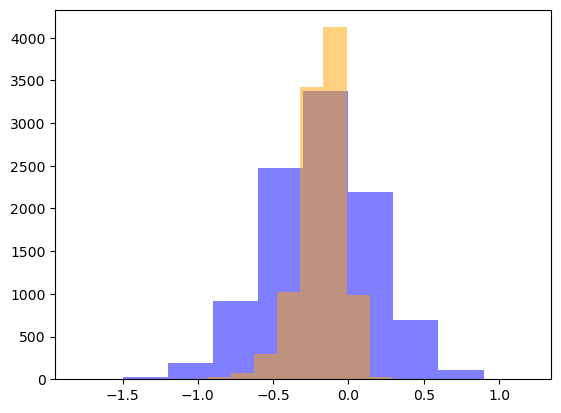

In [23]:
plt.hist(dmu_raw,alpha=0.5, color ='blue')
plt.hist(dmu_corr,alpha=0.5, color ='orange')
print("Raw scatter:",np.std(dmu_raw))
print("Scatter after linear x1 and c correction:",np.std(dmu_corr))

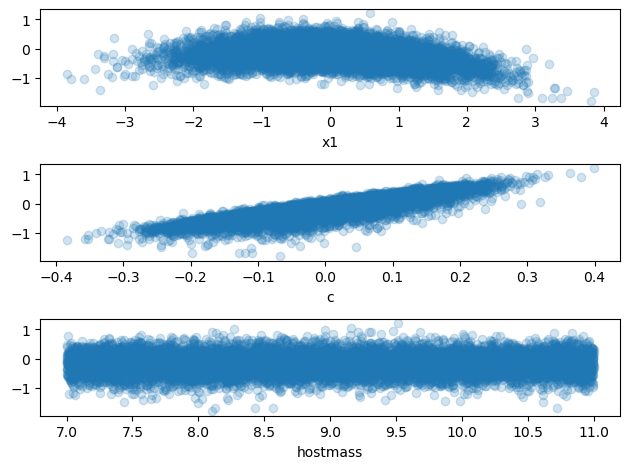

In [24]:
# Hubble residuals (uncorrected) vs SNIa light curve parameters and stuff:


plt.subplot(3,1,1)
plt.scatter(x1, dmu_raw,alpha=0.2)
plt.xlabel('x1')

plt.subplot(3,1,2)
plt.scatter(c, dmu_raw,alpha=0.2)
plt.xlabel('c')

plt.subplot(3,1,3)
plt.scatter(hostmass, dmu_raw,alpha=0.2)
plt.xlabel('hostmass')


plt.tight_layout()
plt.show()

### 2. Now let's see what ML can help.

In [25]:
# Constructing the Random Forest Regressor Model
# Nothing is being fit here, uts just being made.

# Key properties of this model:
# - 1000 trees. 
# - Trees are allowed to grow deep (no max depth)
# - A minimum number of samples per leaf (5) enforces
#   local averaging and limits overfitting
# - At each split, only a subset of features is considered
#   (sqrt of total), encouraging diverse tree structures
# - Bootstrap resampling ensures each tree sees a slightly
#   different realization of the data

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)

In [26]:
# Defining Features and Setting Up Our Train/Test Split

features = {
    "x1": x1,
    "c": c,
    "hostmass": hostmass,
}

X = pd.DataFrame(features)
y = dmu_raw

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:

# Defining standard error as well as weight and fitting the model 
# with all same weighst. In real code each data point would have its own weight to contribute to the fit.
yerr = 0.1
w = 1.0 / (yerr**2)
rf.fit(Xtr, ytr, sample_weight=w)
yhat = rf.predict(Xte)

In [28]:
# Plots feature importance  of x1, c, and hostmass in that order.
rf.feature_importances_

array([0.19403743, 0.77730998, 0.02865259])

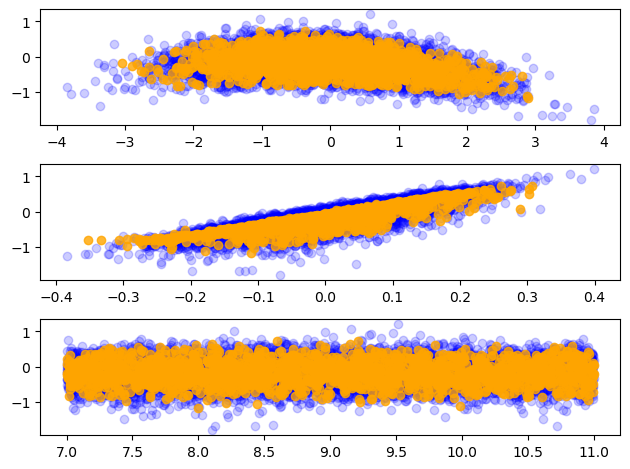

In [38]:
for i,p in enumerate(["x1","c","hostmass"]):
    plt.subplot(3,1,i+1)
    plt.scatter(Xtr[p], ytr,alpha=0.2, color = "blue") # Plots the training sets (loops through the three featuers)
    plt.scatter(Xte[p], yhat,alpha=0.8, color = "orange") # Plots the predicted values. 
plt.tight_layout()

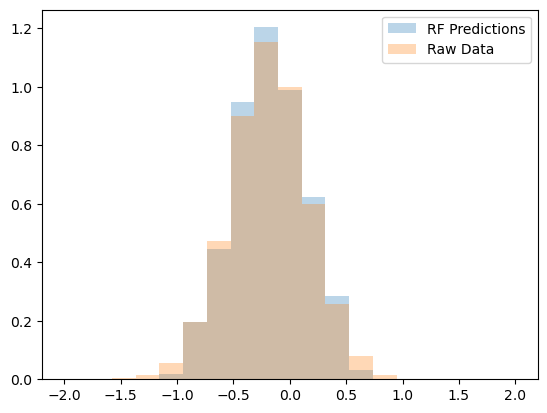

In [30]:
bins = np.linspace(-2,2,20)
plt.hist(yhat,alpha=0.3,density=True,bins=bins,label='RF Predictions')
plt.hist(y,alpha=0.3,density=True,bins=bins,label='Raw Data')
plt.legend()
plt.show()

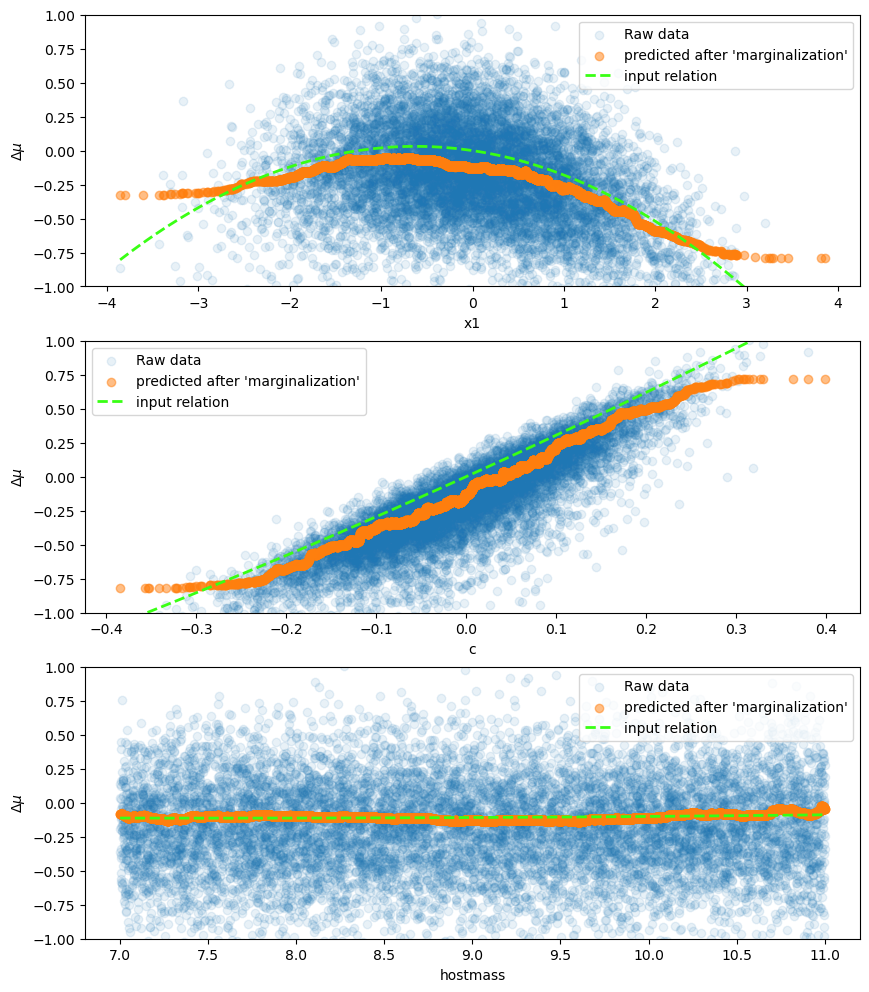

In [ ]:
# We have machine learning model where we can get x1 c and host mass and we get prediction of hubble residuals. Here there is no integration 
# being made but rather a mean value is taken. For Mykola: be sure to actually integrate as part of the marginalization process. 

# What is happening here is called "mean freezing". 

plt.figure(figsize=(10, 12))

# Loops through each of our host features.
for i,p in enumerate(["x1","c","hostmass"]):

    # frames subllots for our data. (i+1 is just an index here)
    plt.subplot(3,1,i+1)

    Xtest = X.copy() # Makes a copy of the features data frame. 

    # Look at the features x1, c, and hostmas. Ingore the one were currently on (p).
    # For each of the remianing features do the following.
    # "Loop thorugh the list of host mass parameter and if they're not equal to the 
    # current parameter p, then take the mean of the other 2  parameters 
    for p2 in [pi for pi in ["x1","c","hostmass"] if pi != p]:
        # Compute a mean of p2 parameters (replacing the whole collumn with the mean value of that column)
        Xtest[p2] = Xtest[p2].mean()
    
    # Predict the hubble residuals using the random forest model after mean averaging over the other 2 parameters.
    ytest = rf.predict(Xtest)


    plt.scatter(Xtest[p],y,alpha=0.1,label="Raw data")
    plt.scatter(Xtest[p],ytest,alpha=0.5,label="predicted after 'marginalization'")

    # Generating a linspace.
    xplot = np.linspace(Xtest[p].min(),Xtest[p].max(),100)

    # Plots both the linear and quadratic components of each training parameter 
    # (whichever is selected in the loop right now). 
    # Checking whether the model’s conditional predictions match the true linear + quadratic relationships that were used to generate the synthetic data.
    if p == "hostmass":
        yplot = -gamma*xplot + gamma2*xplot**2 
    elif p == "x1":
        yplot = -alpha*xplot + alpha2*xplot**2
    elif p == "c":
        yplot = beta*xplot + beta2*xplot**2

    plt.plot(xplot, yplot, color="#39ff14", lw=2, ls="--", label="input relation")

    plt.ylim((-1,1))
    plt.xlabel(p)
    plt.ylabel(r'$\Delta\mu$')
    plt.legend()
plt.show()

0.10910448110997677


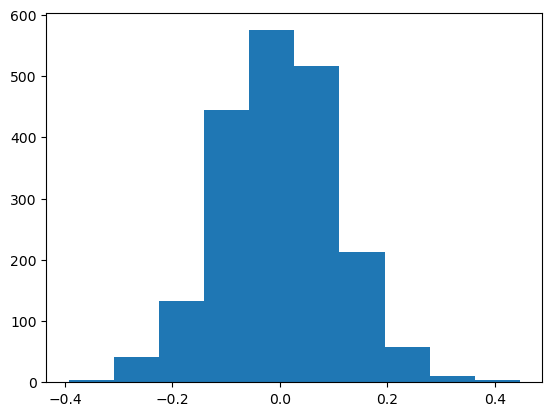

In [32]:
# Make sure to do this as well. 

plt.hist(yhat-yte)
print(np.std(yhat-yte))

Text(0, 0.5, '$\\mu$')

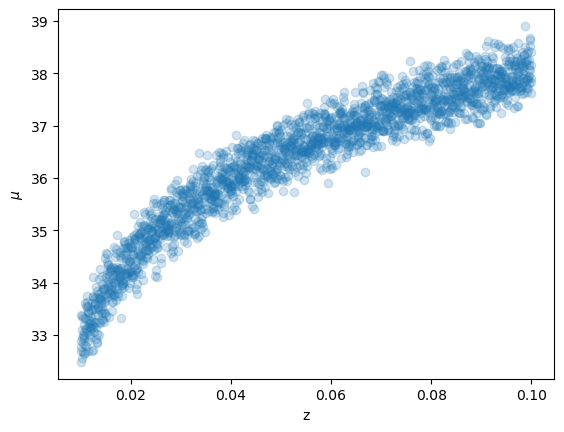

In [ ]:
# Plots cosmology with our predicted residuals. 

cosmo = FlatLambdaCDM(H0=73, Om0=0.3)
z = np.linspace(0.01,0.1,len(yhat))
mu = cosmo.distmod(z).value
mb = yhat + mu
plt.scatter(z,mb,alpha=0.2)
plt.xlabel('z')
plt.ylabel(r'$\mu$')